# Anomaly Detection

In [96]:
# Isolation Forest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

features['anomaly'] = iso_model.fit_predict(X)

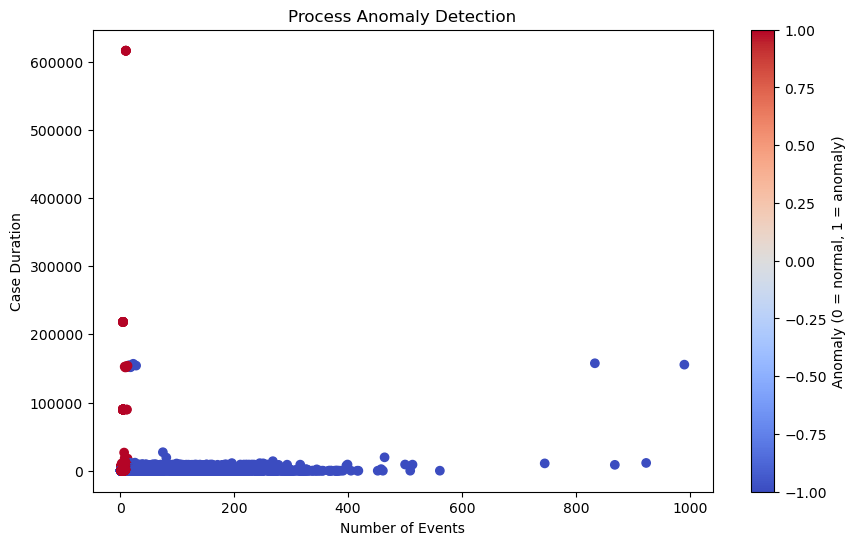

In [102]:
# Visualize Anomalies

plt.figure(figsize=(10,6))

sc = plt.scatter(
    features["num_events"],
    features["duration_hours"],
    c=features["anomaly"],
    cmap="coolwarm"
)

plt.xlabel("Number of Events")
plt.ylabel("Case Duration")
plt.title("Process Anomaly Detection")

cbar = plt.colorbar(sc)
cbar.set_label("Anomaly (0 = normal, 1 = anomaly)")

plt.show()

In [98]:
# Logistic Regression 

model_lr = LogisticRegression()

model_lr.fit(X_train, y_train)

predictions_lr = model_lr.predict(X_test)

In [99]:
# Evaluate Logistic Regression
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, predictions_lr))

print("\nClassification Report:")
print(classification_report(y_test, predictions_lr))

Logistic Regression Accuracy:
0.6461954038969552

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67     25136
           1       0.67      0.57      0.62     25211

    accuracy                           0.65     50347
   macro avg       0.65      0.65      0.64     50347
weighted avg       0.65      0.65      0.64     50347



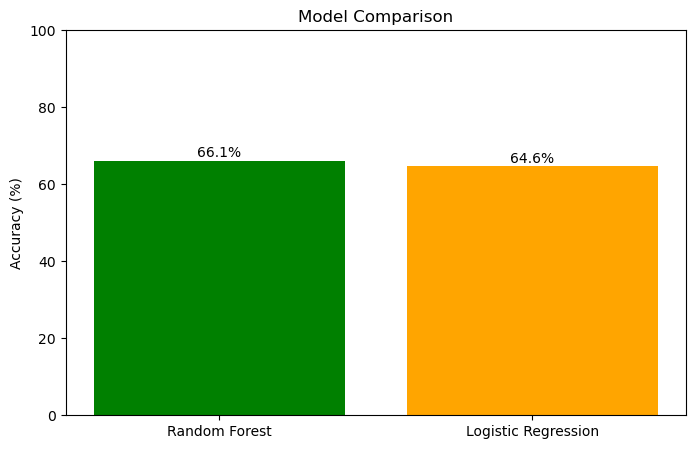

In [105]:
# Compare Models

acc_rf = accuracy_score(y_test, predictions_rf) * 100
acc_lr = accuracy_score(y_test, predictions_lr) * 100

models = ['Random Forest', 'Logistic Regression']
scores = [acc_rf, acc_lr]

plt.figure(figsize=(8,5))
plt.bar(models, scores, color=['green', 'orange'])

plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")

plt.ylim(0, 100)

for i, v in enumerate(scores):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()